<a href="https://colab.research.google.com/github/ty202503337/MIT-209-PROJECT/blob/main/Models/random_forest_classifier_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

csv_file_path = '/content/drive/MyDrive/Datasets/marketing_campaign.csv'

try:
    df = pd.read_csv(csv_file_path, sep='\t')
    print(f"Successfully loaded {csv_file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded /content/drive/MyDrive/Datasets/marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### 1. Data Cleaning and Preprocessing
- Handling missing values in `Income`.
- Cleaning `Age` and filtering outliers.
- Removing duplicates.
- Categorical encoding.

In [5]:
import numpy as np
from datetime import datetime

df = df.drop_duplicates()

df['Income'] = df['Income'].fillna(df['Income'].median())

# Calculate Age
df['Age'] = datetime.now().year - df['Year_Birth']
# Remove unrealistic ages
df = df[(df['Age'] > 0) & (df['Age'] < 100)]
# Remove income outliers
df = df[df['Income'] < 200000]

education_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_Encoded'] = df['Education'].map(education_map)

# One-hot encoding for Marital_Status
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital')

print(f"Data cleaning complete. New shape: {df.shape}")

Data cleaning complete. New shape: (2236, 38)


### 2. Feature Engineering
- Removing irrelevant columns (IDs, PII, redundant dates).
- Scaling numerical features.

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

PII_and_irrelevant = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Education']
spend_cols = [col for col in df.columns if 'Mnt' in col]
cols_to_drop = PII_and_irrelevant + spend_cols

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['Response'])
y = df['Response']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Feature engineering and scaling complete.")

Feature engineering and scaling complete.


### 3. Handle Imbalance & Train Random Forest
Using SMOTE to balance the training set and then training the Random Forest Classifier.

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)

# Evaluate
y_pred = rf_model.predict(X_test)
print("Model Evaluation Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]):.4f}")

Model Evaluation Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       381
           1       0.60      0.52      0.56        67

    accuracy                           0.88       448
   macro avg       0.76      0.73      0.74       448
weighted avg       0.87      0.88      0.87       448

ROC-AUC Score: 0.8705


### 4. Feature Importance Visualization
Features contribute most to the Random Forest model's predictions.

/tmp/ipykernel_6070/2890071211.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


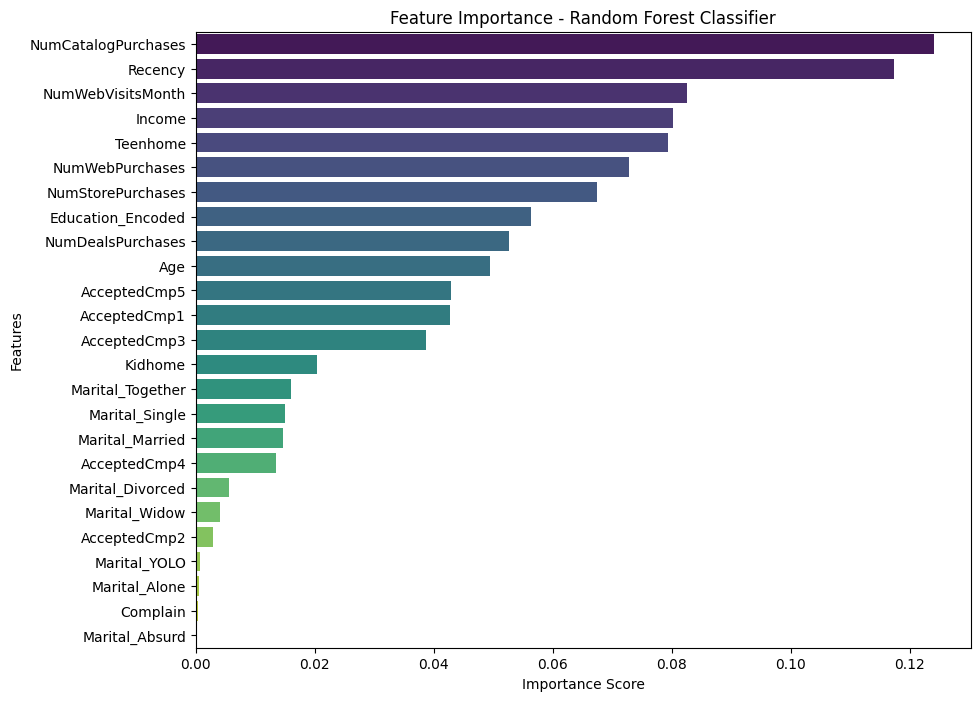

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

--- Random Forest Evaluation Metrics ---
Accuracy:  0.8772
Precision: 0.6034
Recall:    0.5224
F1-Score:  0.5600
ROC-AUC:   0.8705


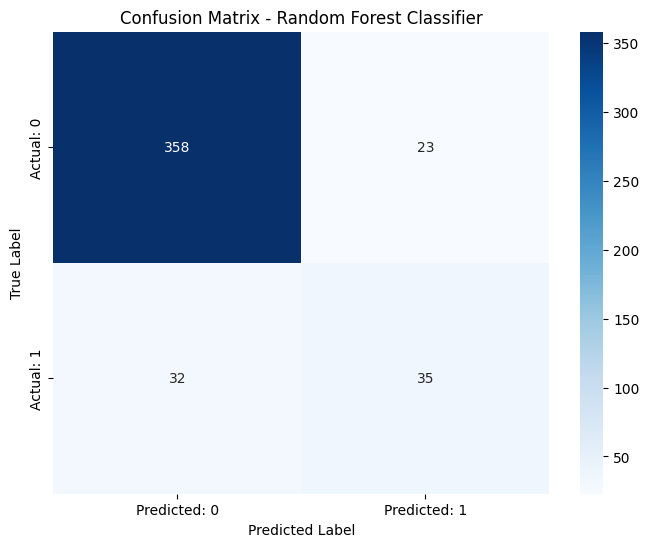

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display metrics
print(f"--- Random Forest Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: 0', 'Predicted: 1'],
            yticklabels=['Actual: 0', 'Actual: 1'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 4. Exporting the Model and Processed Data
Saving the trained `rf_model` and the final cleaned/scaled dataset.

In [13]:
import pickle

model_path = '/content/drive/MyDrive/Datasets/random_forest_marketing_campaign_model.pkl'
data_path = '/content/drive/MyDrive/Datasets/random_forest_marketing_data.csv'

with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

final_df = X_scaled.copy()
final_df['Response'] = y.values
final_df.to_csv(data_path, index=False)

print(f'Model saved to: {model_path}')
print(f'Processed data saved to: {data_path}')

Model saved to: /content/drive/MyDrive/Datasets/random_forest_marketing_campaign_model.pkl
Processed data saved to: /content/drive/MyDrive/Datasets/random_forest_marketing_data.csv


## Summary of Random Forest Evaluation Metrics

| Metric | Value |
| :--- | :--- |
| **Accuracy** | 0.8772 |
| **Precision** | 0.6034 |
| **Recall** | 0.5224 |
| **F1-Score** | 0.5600 |
| **ROC-AUC** | 0.8705 |

### Findings:
- **High Distinguishability**: The ROC-AUC of 0.87 indicates the model is very good at ranking potential responders above non-responders.
- **Precision vs. Recall**: With a precision of ~60%, the model is relatively efficient at identifying likely buyers, helping to save marketing costs. However, the recall of ~52% suggest there is still room to improve on capturing more potential responders.